# Forecasting Annual Global Temperature

Notebook 1 extrapolates tipping point crossing dates from a straight line through the
post-1980 trend. This notebook checks whether that line is good enough: can any model beat
it out of sample?

Setup: expanding window backtest. Each origin year sees only data up to that year, then
predicts 1 or 10 years ahead, against two baselines: persistence (last value forward) and
the linear trend itself.

Sources: NASA GISTEMP v4, NOAA Mauna Loa CO2, NOAA PSL Nino 3.4. pandas, numpy, matplotlib.

## Data

In [1]:
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

plt.rcParams['figure.dpi'] = 130
DATA_DIR = Path('data'); DATA_DIR.mkdir(exist_ok = True)
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


def cached(url, filename):
    path = DATA_DIR / filename
    if not path.exists():
        req = urllib.request.Request(url, headers = {'User-Agent': 'forecast/1.0'})
        with urllib.request.urlopen(req) as r, open(path, 'wb') as f:
            f.write(r.read())
    return path

In [2]:
# GISS publishes anomalies against 1951-1980, so shift them to an 1880-1899
# pre-industrial baseline. Complete years only, so a partial year can't skew the mean.
wide = pd.read_csv(cached('https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv',
                          'global_temp.csv'), skiprows = 1, na_values = ['***'])
assert set(MONTHS) <= set(wide.columns), 'GISTEMP layout changed'

long = wide[['Year'] + MONTHS].melt('Year', var_name = 'month', value_name = 'c').dropna()
long['c'] -= long.loc[long['Year'].between(1880, 1899), 'c'].mean()
counts = long.groupby('Year').size()
annual_temp = (long[long['Year'].isin(counts[counts == 12].index)]
               .groupby('Year')['c'].mean().reset_index())
annual_temp.columns = ['year', 'anomaly_C']

# CO2
co2 = pd.read_csv(cached('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv',
                         'co2_mm_mlo.csv'), comment = '#')
assert {'year', 'average'} <= set(co2.columns), 'NOAA layout changed'
annual_co2 = (co2[co2['average'] > 0].groupby('year')['average']
              .mean().rename('co2_ppm').reset_index())

print(f'temperature {annual_temp.year.min()}-{annual_temp.year.max()}, '
      f'{len(annual_temp)} complete years')

temperature 1880-2025, 146 complete years


### ENSO

Using Nino 3.4 from NOAA PSL instead of CPC's ONI: PSL starts in 1870 (covers the whole
temperature series) vs CPC's 1950, and CPC switched ONI to RONI in February 2026.

Only the previous year's Oct-Dec average enters the models. Current-year ENSO isn't known
at forecast time, so using it would be leakage. Oct-Dec of year t is observed by Dec 31 and
still predicts year t+1, since ENSO takes 3-6 months to show up in global temperature.

In [3]:
lines = cached('https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data',
               'nino34.data').read_text(errors = 'replace').splitlines()

rows = [ln.split() for ln in lines if len(ln.split()) == 13]
nino = (pd.DataFrame(rows, columns = ['year'] + list(range(1, 13))).astype(float)
        .melt('year', var_name = 'month', value_name = 'nino34'))
nino = nino[nino['nino34'] > -90]   # PSL fills gaps with large negatives
assert nino['year'].nunique() > 100, 'PSL layout changed'

ond = nino[nino['month'].isin([10, 11, 12])].groupby('year')['nino34']
enso = ond.mean()[ond.size() == 3].rename('enso_ond').reset_index()

data = (annual_temp.merge(annual_co2, on = 'year', how = 'left')
        .merge(enso, on = 'year', how = 'left').sort_values('year').reset_index(drop = True))
data['enso_prev'] = data['enso_ond'].shift(1)

print(f'{len(data)} years, {data.enso_ond.notna().sum()} with ENSO')

146 years, 146 with ENSO


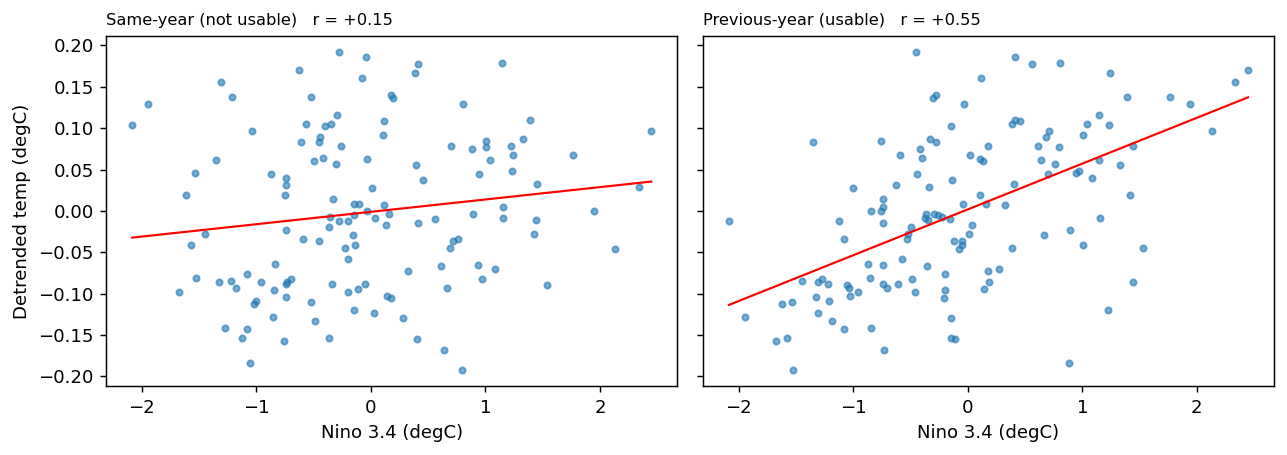

In [4]:
# Detrend first, otherwise both correlations just pick up the warming trend.
data['wobble'] = data['anomaly_C'] - data['anomaly_C'].rolling(15, center = True).mean()
chk = data.dropna(subset = ['wobble', 'enso_ond', 'enso_prev'])

fig, axes = plt.subplots(1, 2, figsize = (10, 3.6), sharey = True)
for ax, col, label in [(axes[0], 'enso_ond', 'Same-year (not usable)'),
                       (axes[1], 'enso_prev', 'Previous-year (usable)')]:
    r = chk['wobble'].corr(chk[col])
    ax.scatter(chk[col], chk['wobble'], s = 12, alpha = 0.6)
    b, a = np.polyfit(chk[col], chk['wobble'], 1)
    xs = np.linspace(chk[col].min(), chk[col].max(), 50)
    ax.plot(xs, a + b * xs, color = 'red', lw = 1.2)
    ax.set_title(f'{label}   r = {r:+.2f}', fontsize = 9, loc = 'left')
    ax.set_xlabel('Nino 3.4 (degC)')
axes[0].set_ylabel('Detrended temp (degC)')
plt.tight_layout(); plt.show()

## Harness

Each model is a function of `(train, horizon)`. The train frame only holds rows at or
before the origin year, so it can't see the target.

Forecasts are direct, not recursive: for a 10-year horizon the model maps year t straight
to t+10, rather than chaining ten one-step forecasts and compounding errors.

In [5]:
TREND_START = 1980


def make_xy(train, horizon, features):
    """Pair the features at year t with the target at year t + horizon."""
    df = train.sort_values('year').reset_index(drop = True).copy()
    df['temp_lag1'] = df['anomaly_C']
    df['temp_lag2'] = df['anomaly_C'].shift(1)
    df['temp_lag3'] = df['anomaly_C'].shift(2)
    df['target'] = df['anomaly_C'].shift(-horizon)

    complete = df[features].notna().all(axis = 1)
    trainable = complete & df['target'].notna()
    return (df.loc[trainable, features].to_numpy(float),
            df.loc[trainable, 'target'].to_numpy(float),
            df.loc[complete, features].to_numpy(float)[-1])


def backtest(data, models, horizon, first_target = 2000, min_train = 40):
    rows = []
    for target in range(first_target, int(data['year'].max()) + 1):
        origin = target - horizon
        train = data[data['year'] <= origin]
        actual = data.loc[data['year'] == target, 'anomaly_C']
        if len(train) < min_train or actual.empty:
            continue
        row = {'origin': origin, 'year': target, 'actual': float(actual.iloc[0])}
        for name, fn in models.items():
            try:
                row[name] = float(fn(train, horizon))
            except Exception as exc:
                row[name] = np.nan
                print(f'  {name} failed at {origin}: {exc}')
        rows.append(row)
    return pd.DataFrame(rows)


def scores(preds, baseline = 'linear_trend'):
    names = [c for c in preds.columns if c not in ('origin', 'year', 'actual')]
    err = preds[names].sub(preds['actual'], axis = 0)
    out = pd.DataFrame({'MAE': err.abs().mean(),
                        'RMSE': np.sqrt((err ** 2).mean()),
                        'bias': err.mean()})
    out['skill'] = 1 - out['MAE'] / out.loc[baseline, 'MAE']
    return out.sort_values('MAE')


def bootstrap_diff(preds, model, baseline = 'linear_trend', n_boot = 10_000, seed = 0):
    """Paired bootstrap on the MAE gap. Negative means the model beat the
    baseline. Paired because every model faces the same target years."""
    err = preds[[model, baseline]].sub(preds['actual'], axis = 0).abs().dropna()
    diff = (err[model] - err[baseline]).to_numpy()
    rng = np.random.default_rng(seed)
    means = diff[rng.integers(0, len(diff), (n_boot, len(diff)))].mean(axis = 1)
    return {'mae_diff': diff.mean(), 'ci_lo': np.percentile(means, 2.5),
            'ci_hi': np.percentile(means, 97.5)}

## Models

In [6]:
def persistence(train, horizon):
    return train.sort_values('year')['anomaly_C'].iloc[-1]


def linear_trend(train, horizon):
    """OLS on year over the post-1980 window. This is what notebook 01 uses."""
    recent = train[train['year'] >= TREND_START]
    slope, intercept = np.polyfit(recent['year'], recent['anomaly_C'], 1)
    return intercept + slope * (train['year'].max() + horizon)


def make_ridge(features, alpha = 1.0):
    """Closed form ridge. Scaling uses training rows only. Scaling on the full
    series first would leak information from the future into the fit."""
    def model(train, horizon):
        X, y, x0 = make_xy(train, horizon, features)
        mu = X.mean(0)
        sd = np.where(X.std(0) == 0, 1.0, X.std(0))
        Xs = np.column_stack([np.ones(len(X)), (X - mu) / sd])
        P = np.eye(Xs.shape[1]) * alpha
        P[0, 0] = 0.0   # don't penalise the intercept
        coef = np.linalg.solve(Xs.T @ Xs + P, Xs.T @ y)
        return np.r_[1.0, (x0 - mu) / sd] @ coef
    return model


FEATURES = ['temp_lag1', 'temp_lag2', 'temp_lag3', 'co2_ppm', 'enso_ond']
models = {'persistence': persistence,
          'linear_trend': linear_trend,
          'ridge': make_ridge(FEATURES),
          'ridge_no_enso': make_ridge([f for f in FEATURES if f != 'enso_ond'])}

In [7]:
# Three checks on the harness. They run every time the notebook runs.

# 1. No leakage. A spy model records the last year it actually gets handed.
#    Corrupting future rows wouldn't test this, because as the origin moves
#    forward those rows become legitimate training data.
seen = []
spy = backtest(data, {'spy': lambda tr, h: seen.append(int(tr['year'].max())) or 0.0}, 10)
assert seen == spy['origin'].tolist()

# 2. Alignment. On a noiseless ramp the target minus the feature-year value
#    has to come out at exactly horizon * slope.
ramp = pd.DataFrame({'year': np.arange(1900, 1981), 'anomaly_C': 0.01 * np.arange(81)})
X_c, y_c, _ = make_xy(ramp, 7, ['temp_lag1'])
assert np.allclose(y_c - X_c[:, 0], 0.07)

# 3. Every prediction sits exactly `horizon` years after its origin.
assert (backtest(data, {'p': persistence}, 10).eval('year - origin') == 10).all()

print('checks passed')

checks passed


## Results

In [8]:
preds1, preds10 = backtest(data, models, 1), backtest(data, models, 10)
scores1, scores10 = scores(preds1), scores(preds10)

print(f'1-year ahead ({len(preds1)} origins, {preds1.year.min()}-{preds1.year.max()})')
display(scores1.round(4))
print(f'\n10-year ahead ({len(preds10)} origins)')
display(scores10.round(4))

1-year ahead (26 origins, 2000-2025)


,MAE,RMSE,bias,skill
ridge,0.0588,0.0776,-0.0208,0.3833
ridge_no_enso,0.0777,0.0959,-0.0192,0.1848
persistence,0.0918,0.1083,-0.0312,0.0379
linear_trend,0.0954,0.1190,-0.0600,0.0000



10-year ahead (26 origins)


,MAE,RMSE,bias,skill
ridge_no_enso,0.1040,0.1360,0.0145,0.2155
ridge,0.1051,0.1369,0.0146,0.2073
linear_trend,0.1326,0.1673,-0.1213,0.0000
persistence,0.2513,0.2825,-0.2421,-0.8947


The 10-year windows overlap almost completely, so the 26 evaluations are worth maybe 2-3
independent ones; the intervals below are optimistic at that horizon.

In [9]:
boot = pd.DataFrame([
    {'horizon': h, 'model': m, **bootstrap_diff(p, m)}
    for h, p in [('1y', preds1), ('10y', preds10)]
    for m in models if m != 'linear_trend'
])
boot['distinguishable'] = np.where((boot.ci_lo < 0) & (boot.ci_hi > 0), 'no', 'yes')
display(boot.round(4))
Markdown('Negative `mae_diff` means the model beat the linear trend. '
         'An interval spanning zero means this record cannot tell them apart.')

,horizon,model,mae_diff,ci_lo,ci_hi,distinguishable
0,1y,persistence,-0.0036,-0.0289,0.0204,no
1,1y,ridge,-0.0366,-0.0605,-0.0139,yes
2,1y,ridge_no_enso,-0.0176,-0.0357,0.0001,no
3,10y,persistence,0.1186,0.0890,0.1486,yes
4,10y,ridge,-0.0275,-0.0757,0.0255,no
5,10y,ridge_no_enso,-0.0286,-0.0778,0.0249,no


Negative `mae_diff` means the model beat the linear trend. An interval spanning zero means this record cannot tell them apart.

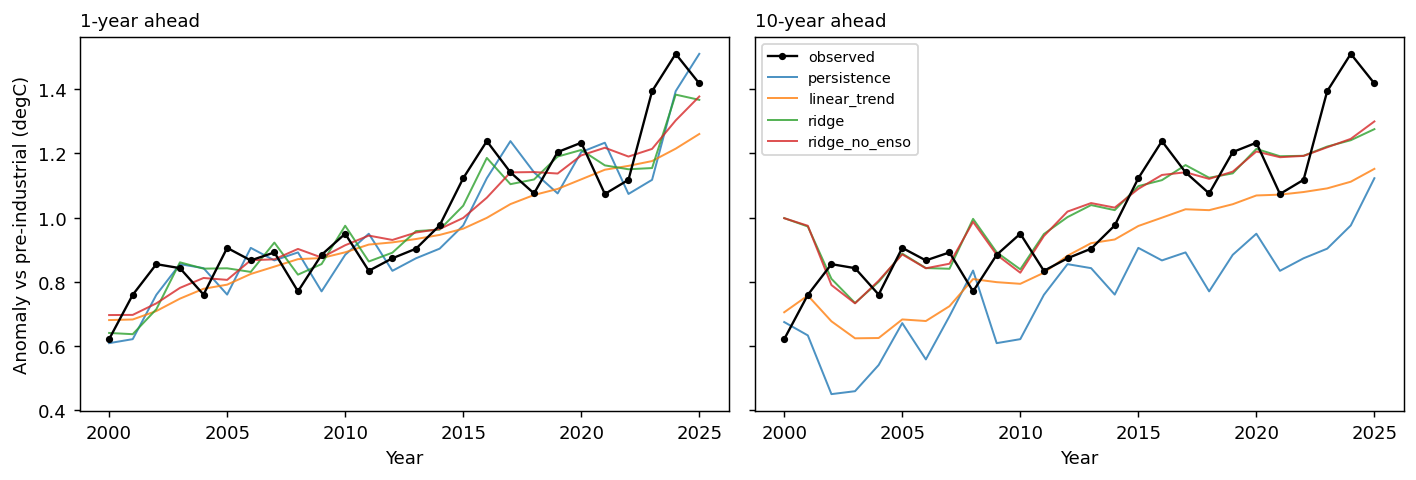

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (11, 3.8), sharey = True)
for ax, preds, label in [(axes[0], preds1, '1-year ahead'),
                         (axes[1], preds10, '10-year ahead')]:
    ax.plot(preds['year'], preds['actual'], 'o-', color = 'black', ms = 3, lw = 1.3,
            label = 'observed', zorder = 5)
    for name in models:
        ax.plot(preds['year'], preds[name], lw = 1.1, alpha = 0.8, label = name)
    ax.set_title(label, fontsize = 10, loc = 'left')
    ax.set_xlabel('Year')
axes[0].set_ylabel('Anomaly vs pre-industrial (degC)')
axes[1].legend(fontsize = 8)
plt.tight_layout(); plt.show()

In [11]:
mae10 = scores10.loc['linear_trend', 'MAE']
slope = np.polyfit(data.loc[data.year >= TREND_START, 'year'],
                   data.loc[data.year >= TREND_START, 'anomaly_C'], 1)[0]

Markdown(f"""
Best at 1 year: `{scores1.index[0]}` (MAE {scores1.MAE.iloc[0]:.3f} degC).
Best at 10 years: `{scores10.index[0]}` (MAE {scores10.MAE.iloc[0]:.3f} degC).

At {slope:.4f} degC/yr, a 10-year MAE of {mae10:.3f} degC is about
**{mae10 / slope:.0f} years** of slack on a crossing date. The Monte Carlo's
threshold uncertainty spans decades to centuries, so the forecast is not the
binding constraint.
""")


Best at 1 year: `ridge` (MAE 0.059 degC).
Best at 10 years: `ridge_no_enso` (MAE 0.104 degC).

At 0.0208 degC/yr, a 10-year MAE of 0.133 degC is about
**6 years** of slack on a crossing date. The Monte Carlo's
threshold uncertainty spans decades to centuries, so the forecast is not the
binding constraint.


## Findings

1. Ridge beats linear trend at 1yr: MAE 0.058 vs 0.095 degC, bootstrap interval clears
   zero. At 10yr it's still ahead but the interval spans zero, not a confirmed gap.

2. Lagged ENSO helps only at short range: takes Ridge from 0.077 to 0.058 degC at 1yr, does
   nothing at 10yr. No decadal ENSO persistence, so its value depends on horizon.

3. Linear trend runs low: bias -0.060 degC at 1yr, -0.121 at 10yr, vs near-zero for Ridge.
   The post-1980 fit isn't keeping up with recent warming, suggesting notebook 01's crossing
   dates land ~6 years too late.

4. Not the main source of error either way: a 10yr MAE of 0.127 degC is ~6 years of slack on
   a crossing date, against threshold uncertainty spanning decades to centuries.

## Limitations

- 26 evaluation points; at 10yr only 2-3 are independent.
- CO2 starts 1958, so CO2 models train on 68 years, not 146.
- Annual data. Monthly would give ~12x the observations, but tipping thresholds are defined
  on annual means.
- No emissions pathway. Every model extrapolates past behaviour.
- No volcanic forcing: matters physically, but no major eruption falls in the 2000-2025
  test window.
- No gradient boosting: trees can't predict outside their training range, and every test
  year is warmer than any training year, so it would only pad the table.
- Ridge alpha fixed at 1.0. Per-fold tuning would help; tuning once on the full series
  would leak.
- One temperature dataset, no observational spread.

## References

GISTEMP Team. *GISS Surface Temperature Analysis (GISTEMP) v4.* NASA GISS.

Lan, X., Tans, P., Thoning, K.W. *Trends in globally-averaged CO2.* NOAA GML.

Rayner, N.A. et al. (2003). Global analyses of sea surface temperature, sea ice, and
night marine air temperature since the late nineteenth century. *J. Geophys. Res.*,
108(D14), 4407. DOI: 10.1029/2002JD002670. Nino 3.4 index calculated at NOAA PSL.

Hyndman, R.J., Athanasopoulos, G. *Forecasting: Principles and Practice*, 3rd ed.,
section 5.10. OTexts.